In [40]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly as py 
import plotly.graph_objs as go

In [41]:
df=pd.read_csv('dataset.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [42]:
# checking for null values 
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [43]:
X=df.iloc[:,[5,6]].values
X

array([[0.0000000e+00, 2.0000000e-01],
       [6.4000000e+01, 0.0000000e+00],
       [0.0000000e+00, 2.0000000e-01],
       ...,
       [1.8425000e+02, 8.3333333e-02],
       [3.4600000e+02, 0.0000000e+00],
       [2.1250000e+01, 0.0000000e+00]], shape=(12330, 2))

Product Duration	Time spent on product pages
Bounce Rate	Leaves after one page

High duration + Low bounce → Interested
Low duration + High bounce → Uninterested

 we are applying k-means Clustring 
 because no labeled data we want to discover patterns automatically 

In [44]:
# ELbow method
from sklearn.cluster import KMeans
WCSS=[]
for i in range(1,11):
    km=KMeans(n_clusters=i,
             init='k-means++',
             max_iter=300,
             n_init=10,
             random_state=0,
             algorithm='lloyd',
             tol=0.001)
    km.fit(X)
    labels=km.labels_
    WCSS.append(km.inertia_)

<function matplotlib.pyplot.show(close=None, block=None)>

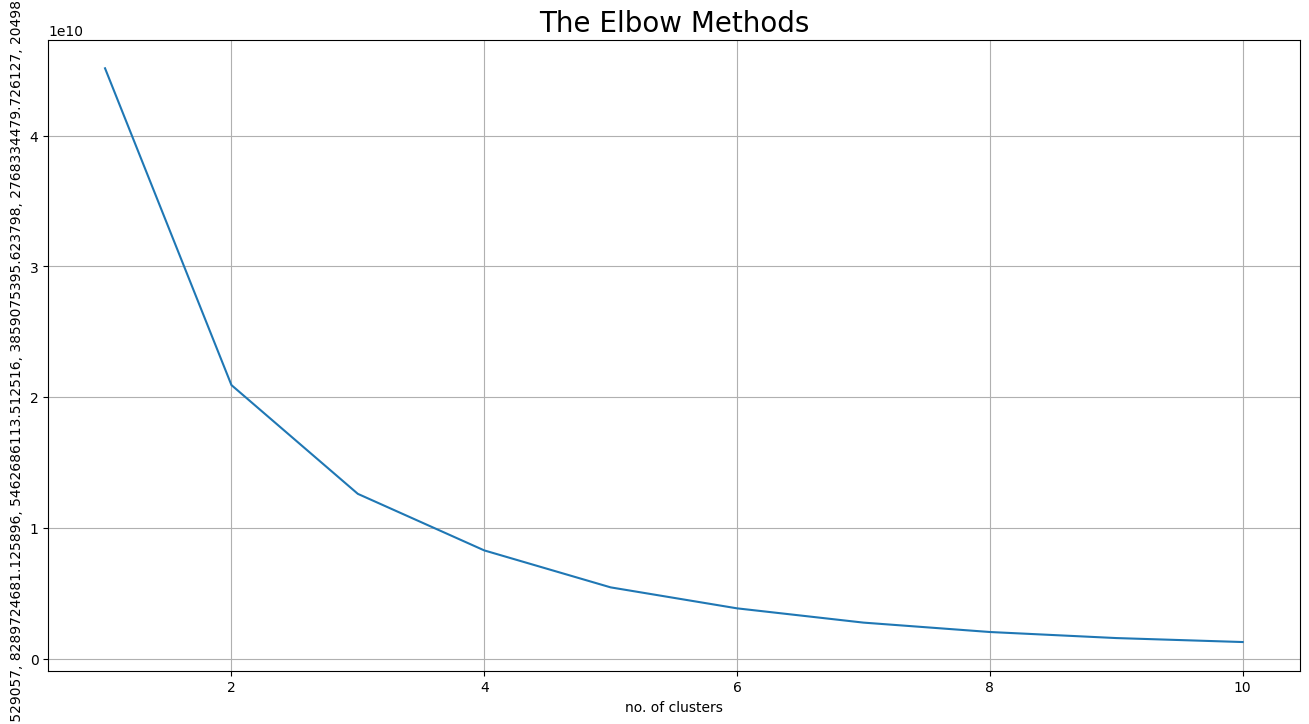

In [45]:
plt.rcParams['figure.figsize']=(13,7)
plt.plot(range(1,11),WCSS)
plt.grid()
plt.tight_layout()
plt.title('The Elbow Methods',fontsize=20)
plt.xlabel('no. of clusters')
plt.ylabel(WCSS)
plt.show

According to the graph above, the maximum curvature is at the second index, that is, the number of optimal clustering groups for the duration of the product and the bounce rates is 2. 
Once the number of clusterings determined, we apply the K Means method and plot the clusters:

In [48]:
km=KMeans(n_clusters=2,
          init='k-means++', 
          max_iter = 300, 
          n_init = 10, 
          random_state = 0)
y_means=km.fit_predict(X)

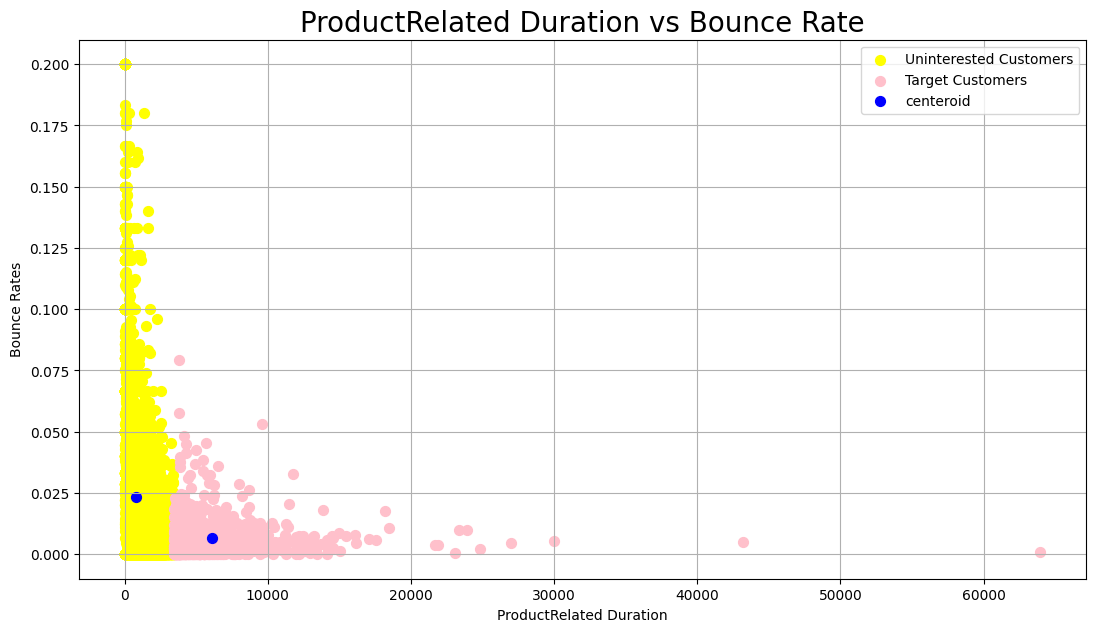

In [49]:
plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1], s = 50, c = 'yellow', label = 'Uninterested Customers')
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1], s = 50, c = 'pink', label = 'Target Customers')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:, 1], s = 50, c = 'blue' , label = 'centeroid')

plt.title('ProductRelated Duration vs Bounce Rate', fontsize = 20)
plt.grid()
plt.xlabel('ProductRelated Duration')
plt.ylabel('Bounce Rates')
plt.legend()
plt.show()

Looking at this K Means grouping plot, we can say with certainty that customers who spent more time on a product-related website are very less likely to leave the website after viewing a single page.

Since K-Means is not a supervised learning method, we are adopting other ways of evaluating its clustering result. The leftmost column of the confusion matrix represents the actual label (True or False revenue), and the top row represents the expected clustering groups (uninterested customers or target customers):

Adjausted rand index
0.08359442469281096


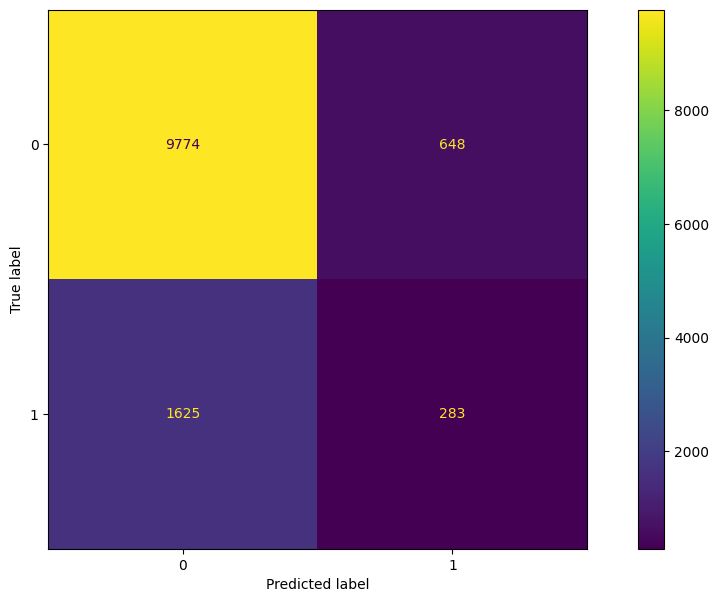

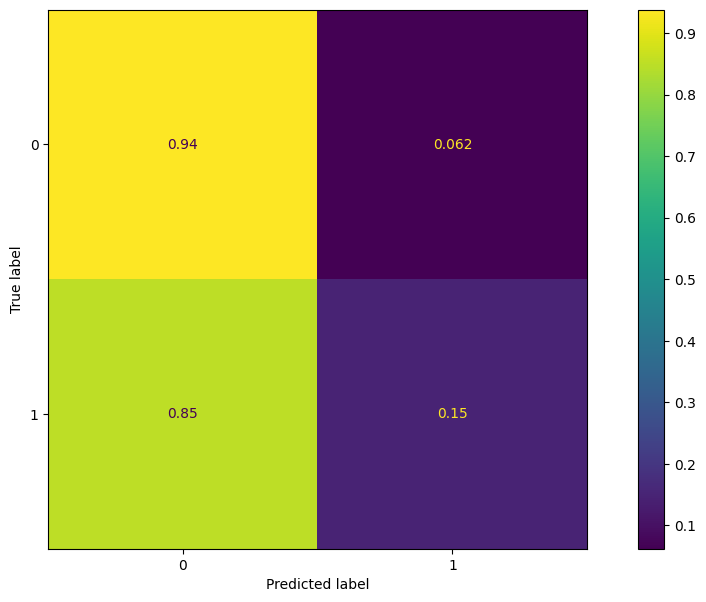

In [66]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
labels_true=le.fit_transform(df['Revenue'])

labels_pred=y_means

from sklearn import metrics
score=metrics.adjusted_rand_score(labels_true,labels_pred)
print("Adjausted rand index")
print(score)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(labels_true, labels_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

cm_norm = confusion_matrix(labels_true, labels_pred, normalize='true')

disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp_norm.plot()
plt.show()

### Observations From Above Plots:
From the confusion matrix, we can see that out of 10,422 failed incomes, 9,769 are grouped into uninterested customers or 94%. However, out of 937 successful incomes, only 284 are grouped as target customers or 15%. Also, the adjusted index score is not very high.

So it is clear that we have poorly bundled many successful revenue sessions as uninterested customers, which means when the high bounce rate combined with a short product-related page duration, there are still a lot of customers. targets.